In [2]:
# Import required libraries for data analysis and visualization
import os, glob, pandas as pd, seaborn as sns, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

In [3]:
import re

# Load master heatmap CSV files from current directory
csv_files = glob.glob("master_heatmap*.csv")  # Find all CSV files in current directory

def extract_teff_bin(filename):
    match = re.search(r'(\d{4})_(\d{4})_K', filename)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    return None

# Load and combine all CSV files into a single dataframe, adding temperature bin
df = pd.DataFrame()
for f in csv_files:
    temp_bin = extract_teff_bin(f)
    temp_df = pd.read_csv(f)
    temp_df['teff_bin'] = temp_bin
    df = pd.concat([df, temp_df], ignore_index=True)

print(f"Combined dataframe shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.head())



Combined dataframe shape: (504, 7)
Columns: ['True Radius (Earth Radii)', 'True Period (Days)', 'detections', 'trials', 'transit_prob', 'detection_rate', 'teff_bin']
   True Radius (Earth Radii)  True Period (Days)  detections  trials  \
0                        1.4               0.700          46      66   
1                        1.4               1.270          39      66   
2                        1.4               2.305          28      66   
3                        1.4               4.183          20      66   
4                        1.4               7.591          14      66   

   transit_prob  detection_rate   teff_bin  
0      0.252196        0.696970  4000_4500  
1      0.169538        0.590909  4000_4500  
2      0.113944        0.424242  4000_4500  
3      0.076585        0.303030  4000_4500  
4      0.051476        0.212121  4000_4500  


Period values: [ 0.7    1.27   2.305  4.183  7.591 13.776 25.   ]
Period log values: [-0.15490196  0.10380372  0.36267093  0.62148786  0.88029899  1.13912313
  1.39794001]
Period bin edges: [0.5196910044992892, 0.9428679653058534, 1.7109500284929424, 3.1051272115647697, 5.6349936113539645, 10.226124192478789, 18.55801713545928, 33.67816698508144]
Number of bins: 7


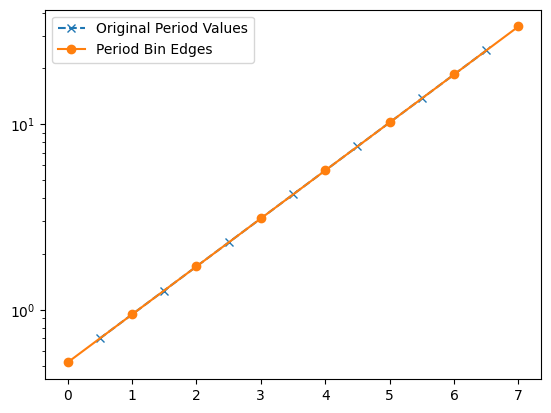

Radius values: [1.4  1.81 2.33 3.   3.88 5.  ]
Radius log values: [0.14612804 0.25767857 0.36735592 0.47712125 0.58883173 0.69897   ]
Radius bin edges: [1.231268492022562, 1.5918542646863123, 2.0536065835500237, 2.6438608132804573, 3.411744421846396, 4.404543109109048, 5.675957614831249]
Number of bins: 6


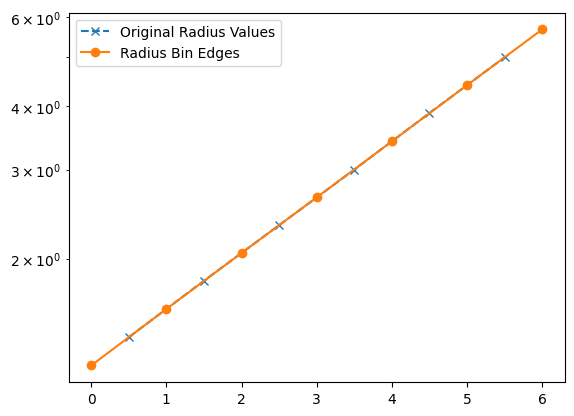

In [4]:
# Generate log-spaced bin edges for True Period values
period_vals = np.array(sorted(df['True Period (Days)'].unique()))  # Get unique period values

# Calculate log-space halfway points between adjacent values
period_log = np.log10(period_vals)  # Convert to log space
period_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = period_log[1] - period_log[0]  # Log spacing between first two values
first_edge = 10**(period_log[0] - log_step/2)  # Extrapolate backward by half step
period_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(period_log) - 1):
    halfway_log = (period_log[i] + period_log[i+1]) / 2  # Midpoint in log space
    period_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = period_log[-1] - period_log[-2]  # Log spacing between last two values
last_edge = 10**(period_log[-1] + log_step/2)  # Extrapolate forward by half step
period_bin_edges.append(last_edge)

# Print results for verification
print(f"Period values: {period_vals}")
print(f"Period log values: {period_log}")
print(f"Period bin edges: {period_bin_edges}")
print(f"Number of bins: {len(period_bin_edges) - 1}")

# Plot to visualize period values vs bin edges
period_vals_x_axis = np.arange(len(period_vals)) + 0.5  # Offset for visualization
plt.plot(period_vals_x_axis, period_vals, 'x--', label='Original Period Values')
plt.plot(period_bin_edges, 'o-', label='Period Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()

# Generate log-spaced bin edges for True Radius values (same method as periods)
radius_vals = np.array(sorted(df['True Radius (Earth Radii)'].unique()))  # Get unique radius values

# Calculate log-space halfway points between adjacent values
radius_log = np.log10(radius_vals)  # Convert to log space
radius_bin_edges = []

# First edge: extrapolate backward using same log spacing as first interval
log_step = radius_log[1] - radius_log[0]  # Log spacing between first two values
first_edge = 10**(radius_log[0] - log_step/2)  # Extrapolate backward by half step
radius_bin_edges.append(first_edge)

# Middle edges: halfway points in log space between adjacent values
for i in range(len(radius_log) - 1):
    halfway_log = (radius_log[i] + radius_log[i+1]) / 2  # Midpoint in log space
    radius_bin_edges.append(10**halfway_log)  # Convert back to linear space

# Last edge: extrapolate forward using same log spacing as last interval
log_step = radius_log[-1] - radius_log[-2]  # Log spacing between last two values
last_edge = 10**(radius_log[-1] + log_step/2)  # Extrapolate forward by half step
radius_bin_edges.append(last_edge)

# Print results for verification
print(f"Radius values: {radius_vals}")
print(f"Radius log values: {radius_log}")
print(f"Radius bin edges: {radius_bin_edges}")
print(f"Number of bins: {len(radius_bin_edges) - 1}")

# Plot to visualize radius values vs bin edges
radius_vals_x_axis = np.arange(len(radius_vals)) + 0.5  # Offset for visualization
plt.plot(radius_vals_x_axis, radius_vals, 'x--', label='Original Radius Values')
plt.plot(radius_bin_edges, 'o-', label='Radius Bin Edges')
plt.legend()
plt.yscale('log')  # Log scale for better visualization
plt.show()



In [5]:
# Assign bin min/max edges for each row using pd.cut with labels as bin index, then map to edge values
df['radius_bin'] = pd.cut(df['True Radius (Earth Radii)'], bins=radius_bin_edges, include_lowest=True, labels=False)
df['period_bin'] = pd.cut(df['True Period (Days)'], bins=period_bin_edges, include_lowest=True, labels=False)
df['radius_bin_min'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['radius_bin_max'] = df['radius_bin'].apply(lambda x: radius_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
df['period_bin_min'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)] if pd.notnull(x) else np.nan)
df['period_bin_max'] = df['period_bin'].apply(lambda x: period_bin_edges[int(x)+1] if pd.notnull(x) else np.nan)
print(df.head())

   True Radius (Earth Radii)  True Period (Days)  detections  trials  \
0                        1.4               0.700          46      66   
1                        1.4               1.270          39      66   
2                        1.4               2.305          28      66   
3                        1.4               4.183          20      66   
4                        1.4               7.591          14      66   

   transit_prob  detection_rate   teff_bin  radius_bin  period_bin  \
0      0.252196        0.696970  4000_4500           0           0   
1      0.169538        0.590909  4000_4500           0           1   
2      0.113944        0.424242  4000_4500           0           2   
3      0.076585        0.303030  4000_4500           0           3   
4      0.051476        0.212121  4000_4500           0           4   

   radius_bin_min  radius_bin_max  period_bin_min  period_bin_max  
0        1.231268        1.591854        0.519691        0.942868  
1        1

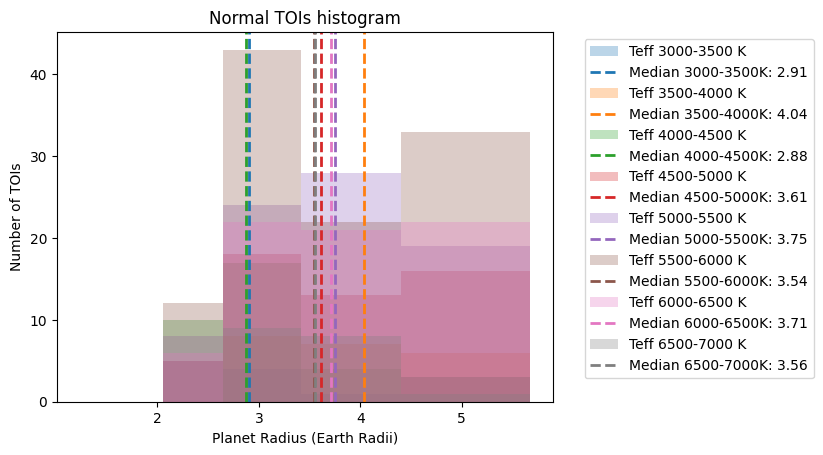

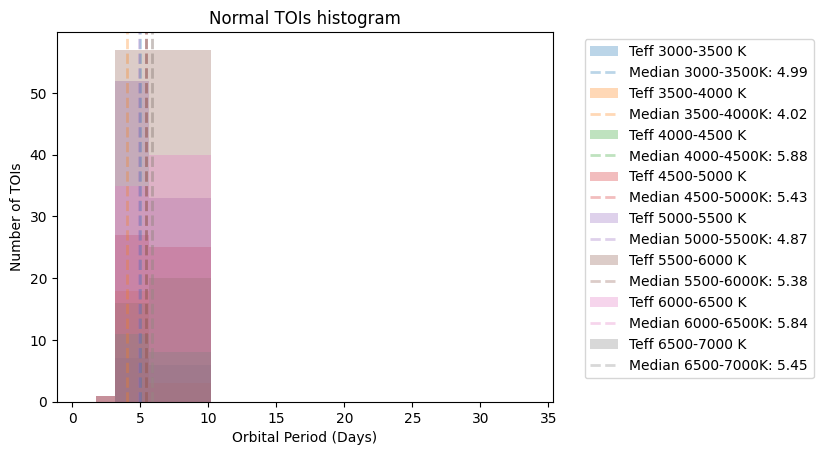

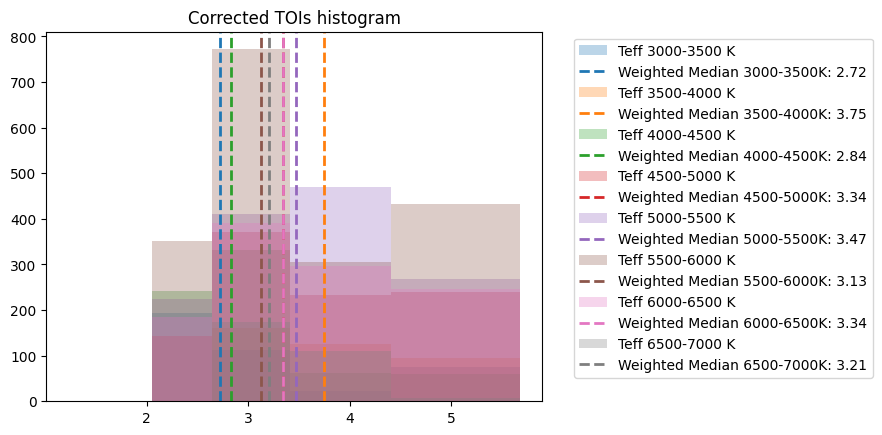

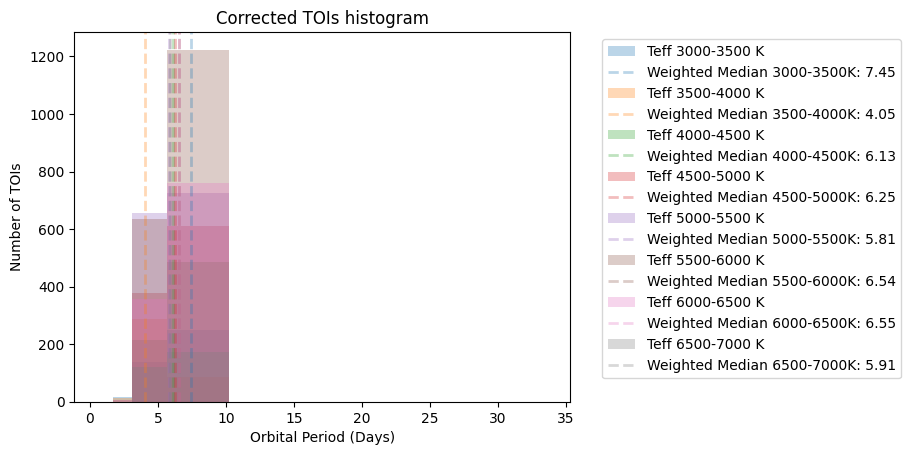

Rows with any NaNs in merged_df: 21
Rows with NaNs in merged_df:
         toi  st_teff   pl_rade  pl_orbper   teff_bin  radius_bin_min  \
10   7181.01  5946.00  5.828300   5.179440  5500_6000             NaN   
11   5953.01  5242.00  5.731250   7.492456  5000_5500             NaN   
16   4388.01  5225.05  5.744920   4.474234  5000_5500             NaN   
36   4657.01  6200.00  5.854373   8.115667  6000_6500             NaN   
74   6199.01  5366.00  5.750030   3.831180  5000_5500             NaN   
82   6682.01  5372.00  5.758484   4.243624  5000_5500             NaN   
83   6792.01  5081.50  5.943440   7.960591  5000_5500             NaN   
101  4245.01  5093.00  5.716850   3.152718  5000_5500             NaN   
118  2802.01  5668.00  5.794790   3.526661  5500_6000             NaN   
120  2908.01  6788.00  5.857930   5.463102  6500_7000             NaN   
121  3105.01  6068.00  5.822790   5.333257  6000_6500             NaN   
131  3884.01  3192.00  5.717700   4.544557  3000_3500      

In [89]:
 
TOIs = pd.read_csv('../TOI_Mar2025_0to6_R.csv')

# Define temperature ranges matching our completeness data
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

#teff_ranges = [(t, t + 1000) for t in range(3000, 7000, 1000)]
lower_period_bound = 3
upper_period_bound = 10

# Filter TOIs data
TOIs_filtered = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_rade'] > 2.5) & (TOIs_filtered['pl_rade'] < 6)]
TOIs_filtered = TOIs_filtered[(TOIs_filtered['pl_orbper'] > lower_period_bound) & (TOIs_filtered['pl_orbper'] < upper_period_bound)]
#TOIs_filtered = TOIs_filtered[~TOIs_filtered['id'].isin([80224448, 370009806])] # The ones with giant corrections
#TOIs_filtered = TOIs_filtered[(TOIs_filtered['ruwe'] <= 1.4)]

# Remove false positives if column exists
if 'tfopwg_disp' in TOIs_filtered.columns:
    TOIs_filtered = TOIs_filtered[TOIs_filtered['tfopwg_disp'] != 'FP']

TOIs_filtered = TOIs_filtered[['toi', 'st_teff', 'pl_rade', 'pl_orbper']]

radius_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

period_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]
#print(TOIs_filtered)

#print(radius_bins)
#print(period_bins)

for row in TOIs_filtered.itertuples():
    teff = row.st_teff
    radius = row.pl_rade
    period = row.pl_orbper
    
    # Determine which temperature bin the TOI falls into
    for teff_min, teff_max in teff_ranges:
        if teff_min <= teff < teff_max:
            teff_bin = f"{teff_min}_{teff_max}"
            TOIs_filtered.at[row.Index, 'teff_bin'] = teff_bin
    
    for rad_min, rad_max in radius_bins:
        if rad_min <= radius < rad_max:
            radius_bin_min = rad_min
            radius_bin_max = rad_max
            TOIs_filtered.at[row.Index, 'radius_bin_min'] = radius_bin_min
            TOIs_filtered.at[row.Index, 'radius_bin_max'] = radius_bin_max

    for per_min, per_max in period_bins:
        if per_min <= period < per_max:
            period_bin_min = per_min
            period_bin_max = per_max
            TOIs_filtered.at[row.Index, 'period_bin_min'] = period_bin_min
            TOIs_filtered.at[row.Index, 'period_bin_max'] = period_bin_max

#print(TOIs_filtered)
  
# Merge TOIs with completeness data
merged_df = pd.merge(TOIs_filtered, df, on=['teff_bin', 'radius_bin_min', 'radius_bin_max', 'period_bin_min', 'period_bin_max'], how='left')
#print(merged_df)

#### REGULAR HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_rade'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Planet Radius (Earth Radii)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3, label=f'Teff {temp_range[0]}-{temp_range[1]} K')
    hist_color = patches[0].get_facecolor()
    median_val = teff_df['pl_orbper'].median()
    plt.axvline(median_val, linestyle='--', linewidth=2, color=hist_color, label=f'Median {temp_range[0]}-{temp_range[1]}K: {median_val:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Normal TOIs histogram')
plt.show()
########

# calculate inverse detection and transit probabilities
for row in merged_df.itertuples():
    detection_rate = row.detection_rate
    transit_prob = row.transit_prob

    # Only update detection_inverse and transit_inverse, leave other columns untouched
    if pd.notnull(detection_rate) and detection_rate > 0:
        merged_df.at[row.Index, 'detection_inverse'] = 1/detection_rate
    else:
        merged_df.at[row.Index, 'detection_inverse'] = np.nan

    if pd.notnull(transit_prob) and transit_prob > 0:
        merged_df.at[row.Index, 'transit_inverse'] = 1/transit_prob
    else:
        merged_df.at[row.Index, 'transit_inverse'] = np.nan
#print(merged_df)

#merged_df to csv
#merged_df[['toi', 'detection_inverse', 'transit_inverse']].to_csv('merged_df.csv', index=False)

# Duplicate each row of merged_df according to a per-row count value in a new column 'row_count'
# First, define how you want to calculate 'weight' for each row. 
# Example: here we use detection_inverse * transit_inverse rounded to nearest int, but you can change this logic.
merged_df['weight'] = (merged_df['detection_inverse'] * merged_df['transit_inverse']).fillna(1)
#merged_df['mult_count'] = np.where(merged_df['mult_count'] >= 1, merged_df['mult_count'] - 1, merged_df['mult_count'])
#print(merged_df[['toi', 'detection_rate', 'transit_prob', 'detection_inverse', 'transit_inverse', 'mult_count']])

#print(merged_df)
#print(merged_df[['toi', 'detection_inverse', 'transit_inverse', 'row_count']])
# Now repeat each row according to its 'row_count' value
#merged_df_corrected = merged_df#.loc[merged_df.index.repeat(merged_df['mult_count'])].reset_index(drop=True)

radius_medians = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)'])
###CORRECTED HISTOGRAM
for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_rade'], bins=radius_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        radius_medians = pd.concat([
            radius_medians,
            pd.DataFrame({
            'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
            'Weighted Median Radius (Earth Radii)': [weighted_median]
            })], ignore_index=True)
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}', alpha=1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Corrected TOIs histogram')
plt.show()

#radius_medians.to_csv('corrected_medians.csv', index=False)

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    n, bins, patches = plt.hist(teff_df['pl_orbper'], bins=period_bin_edges, alpha=0.3,  label=f'Teff {temp_range[0]}-{temp_range[1]} K', weights=teff_df['weight'])
    hist_color = patches[0].get_facecolor()
    # Calculate weighted median
    vals = teff_df['pl_orbper'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
        plt.axvline(weighted_median, linestyle='--', linewidth=2, color=hist_color, label=f'Weighted Median {temp_range[0]}-{temp_range[1]}K: {weighted_median:.2f}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel('Orbital Period (Days)')
    plt.ylabel('Number of TOIs')
    plt.title('Corrected TOIs histogram')
plt.show()
#######

#print how many rows have NaNs in merged_df
print("Rows with any NaNs in merged_df:", merged_df.isnull().any(axis=1).sum())
print("Rows with NaNs in merged_df:")
print(merged_df[merged_df.isnull().any(axis=1)])

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_64124/2806358040.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax.plot(m1, m2, 'k.', markersize=10, c='white')


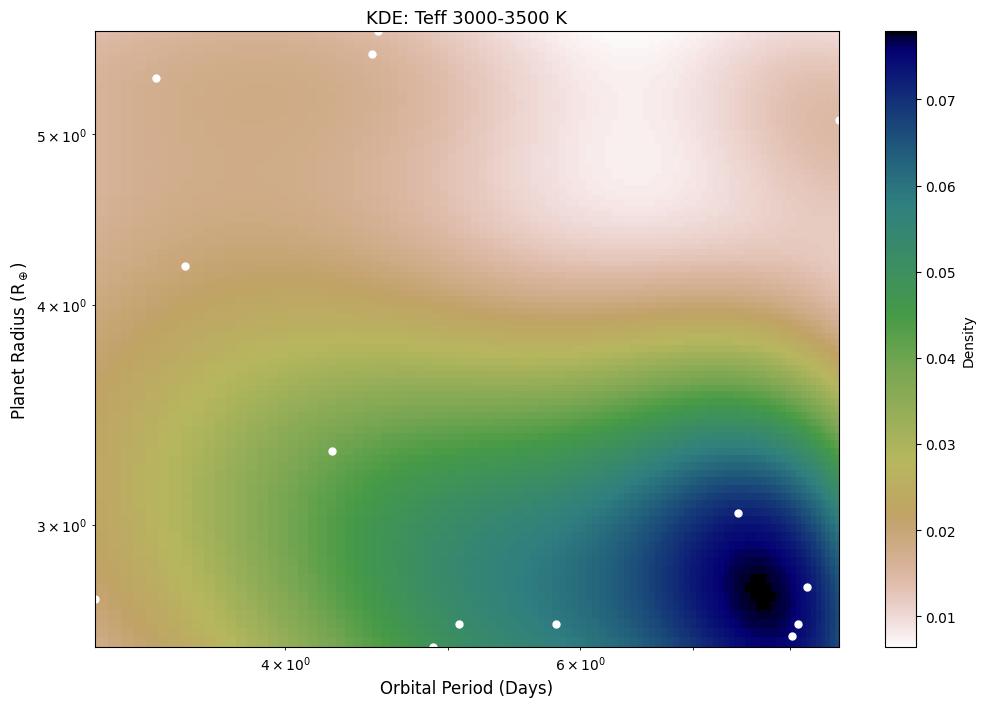

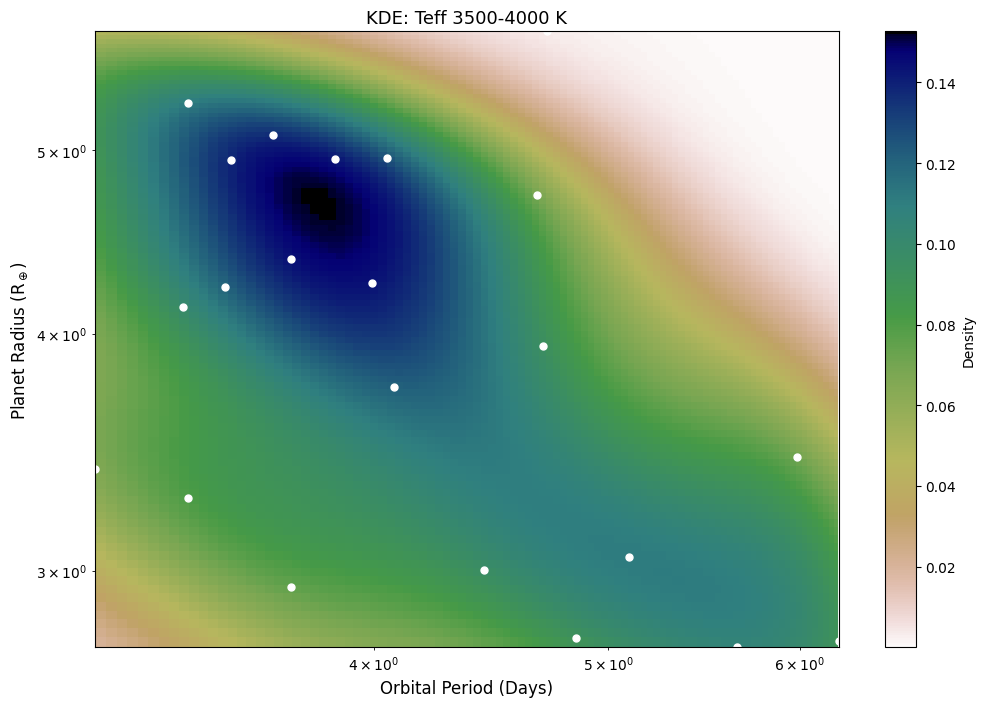

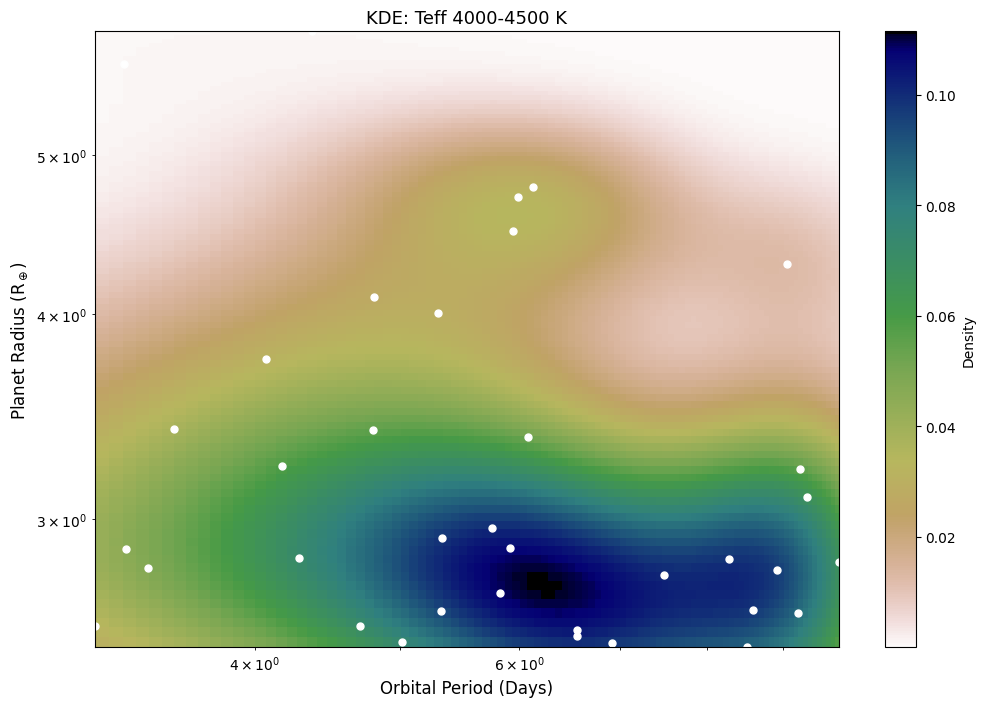

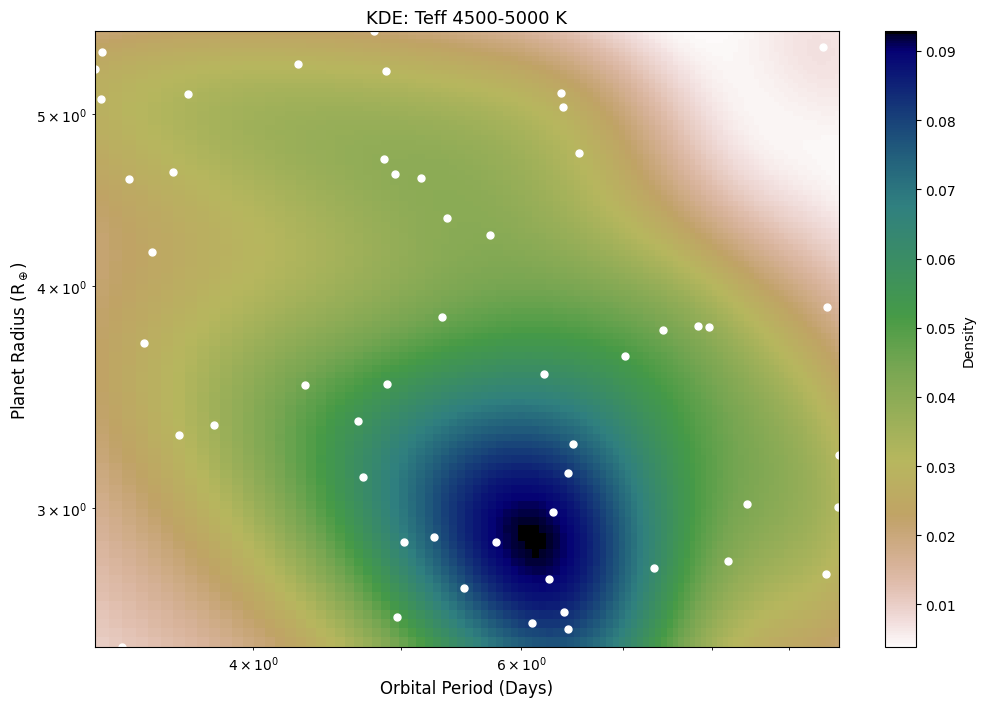

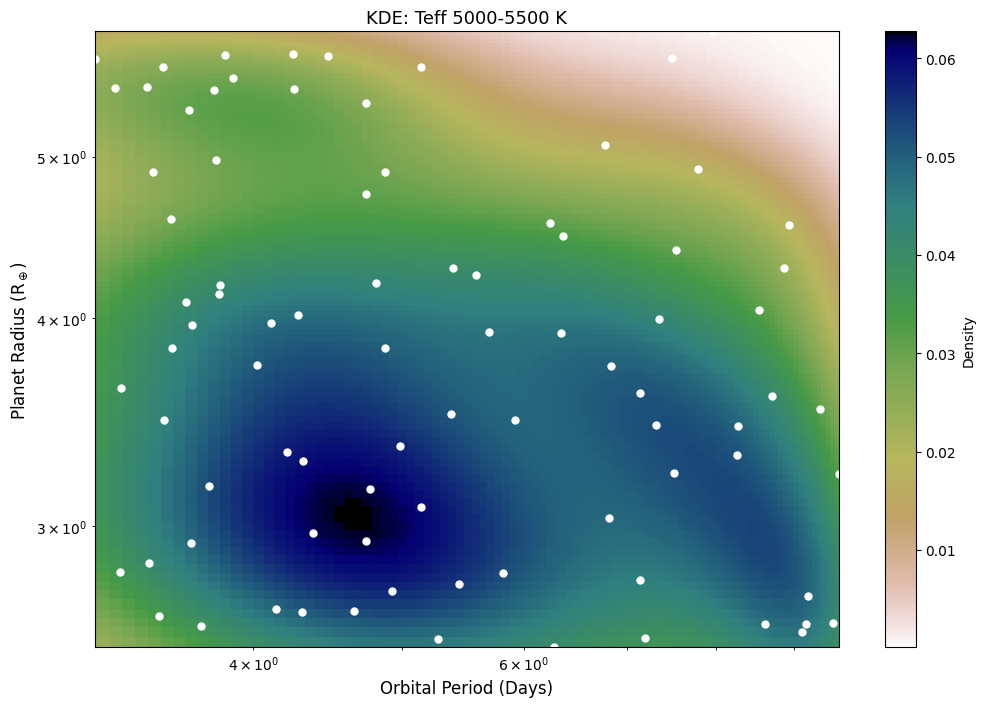

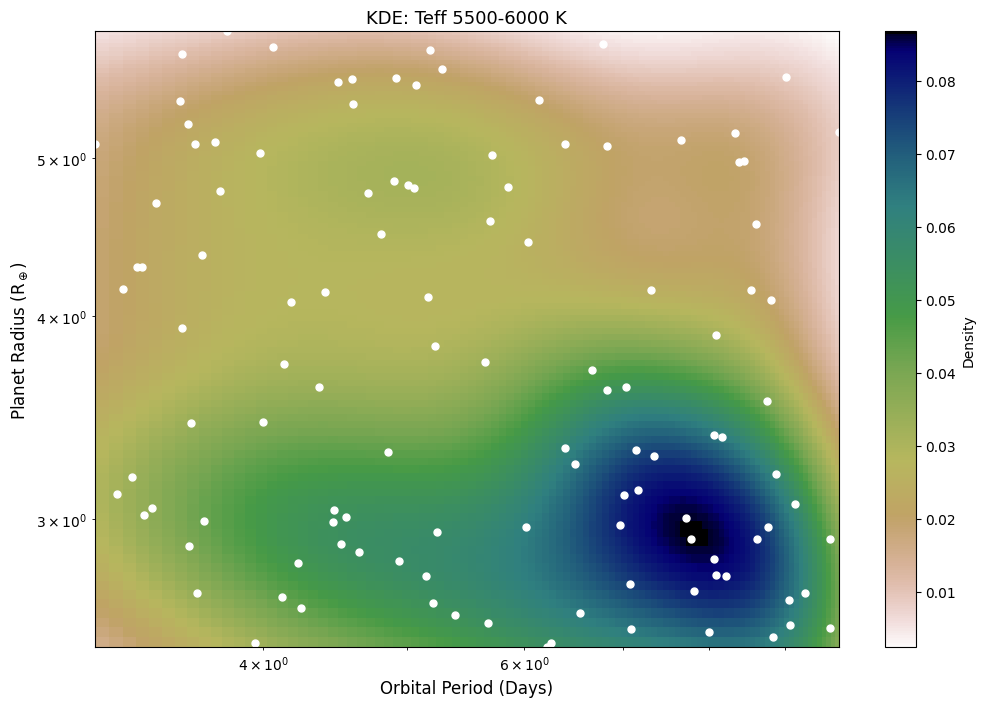

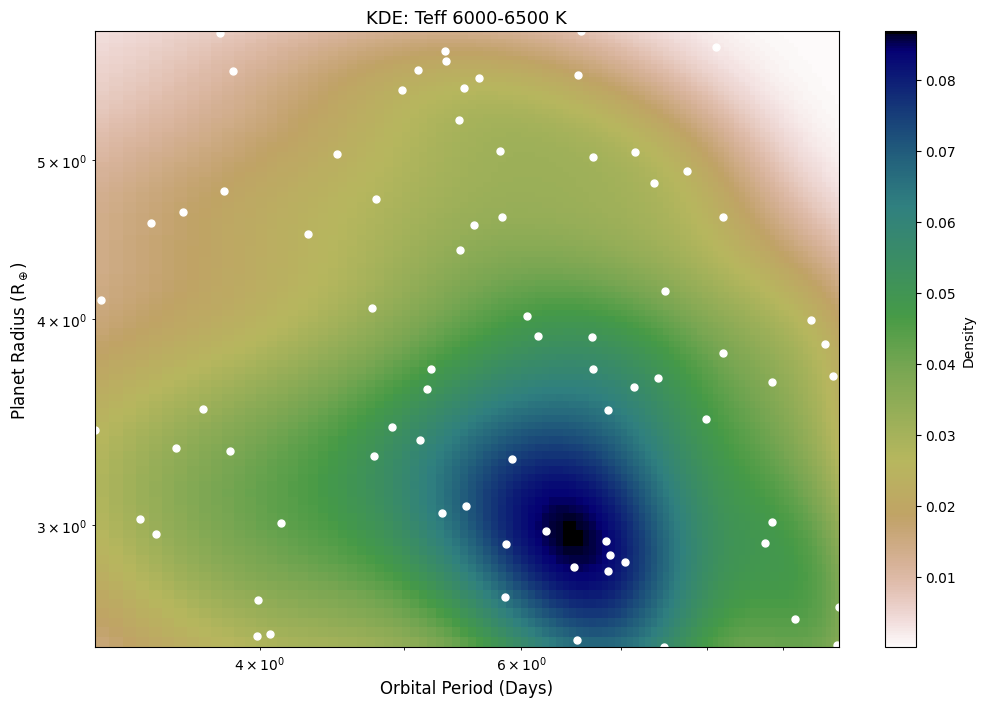

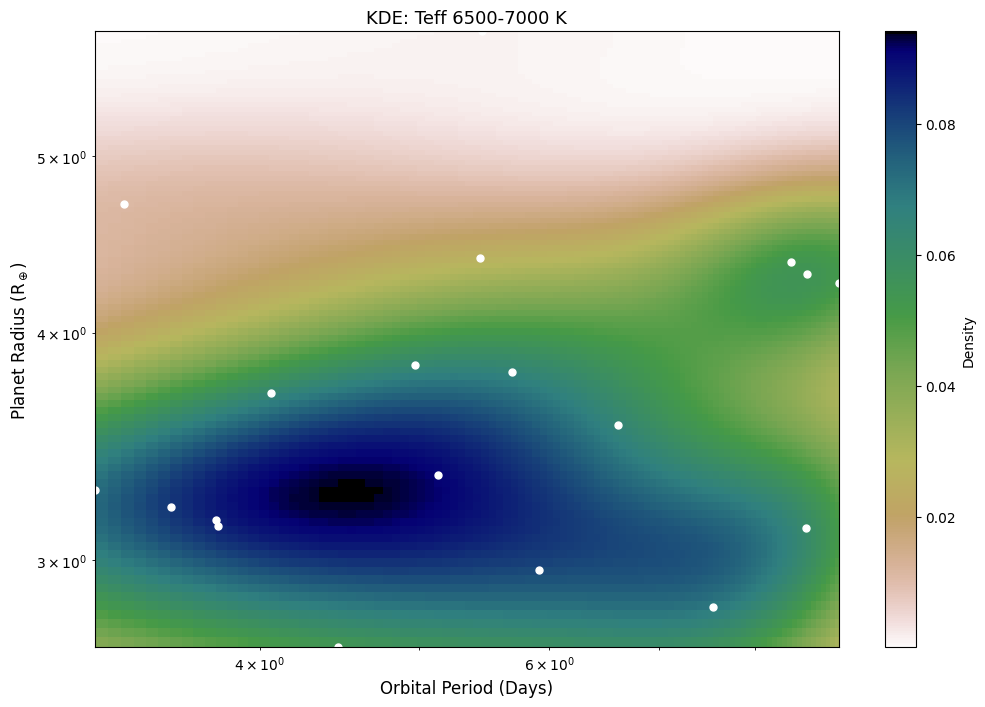

In [90]:
from scipy import stats

for temp_range in teff_ranges:
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    # Calculate weighted median
    radii = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    periods = teff_df['pl_orbper'].values

    # plt.scatter(periods, radii)
    # plt.xlabel('Orbital Period (Days)')
    # plt.ylabel('Planet Radius (Earth Radii)')
    # plt.title(f'TOIs: Teff {temp_range[0]}-{temp_range[1]} K')
    # plt.show()


    m1, m2 = periods, radii
    xmin = m1.min()
    xmax = m1.max()
    ymin = m2.min()
    ymax = m2.max()

    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([m1, m2])
    kernel = stats.gaussian_kde(values, weights=weights)
    Z = np.reshape(kernel(positions).T, X.shape)

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
            extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax.plot(m1, m2, 'k.', markersize=10, c='white')
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Orbital Period (Days)', fontsize=12)
    ax.set_ylabel('Planet Radius (R$_\oplus$)', fontsize=12)
    ax.set_title(f'KDE: Teff {temp_range[0]}-{temp_range[1]} K', fontsize=13)
    plt.colorbar(im, ax=ax, label='Density')
    plt.show()

    
plt.show()

3000-3500 K: Total corrected TOIs = 403.2
3500-4000 K: Total corrected TOIs = 383.1
4000-4500 K: Total corrected TOIs = 698.9
4500-5000 K: Total corrected TOIs = 988.0
5000-5500 K: Total corrected TOIs = 1378.8
5500-6000 K: Total corrected TOIs = 1865.9
6000-6500 K: Total corrected TOIs = 1123.7
6500-7000 K: Total corrected TOIs = 293.0


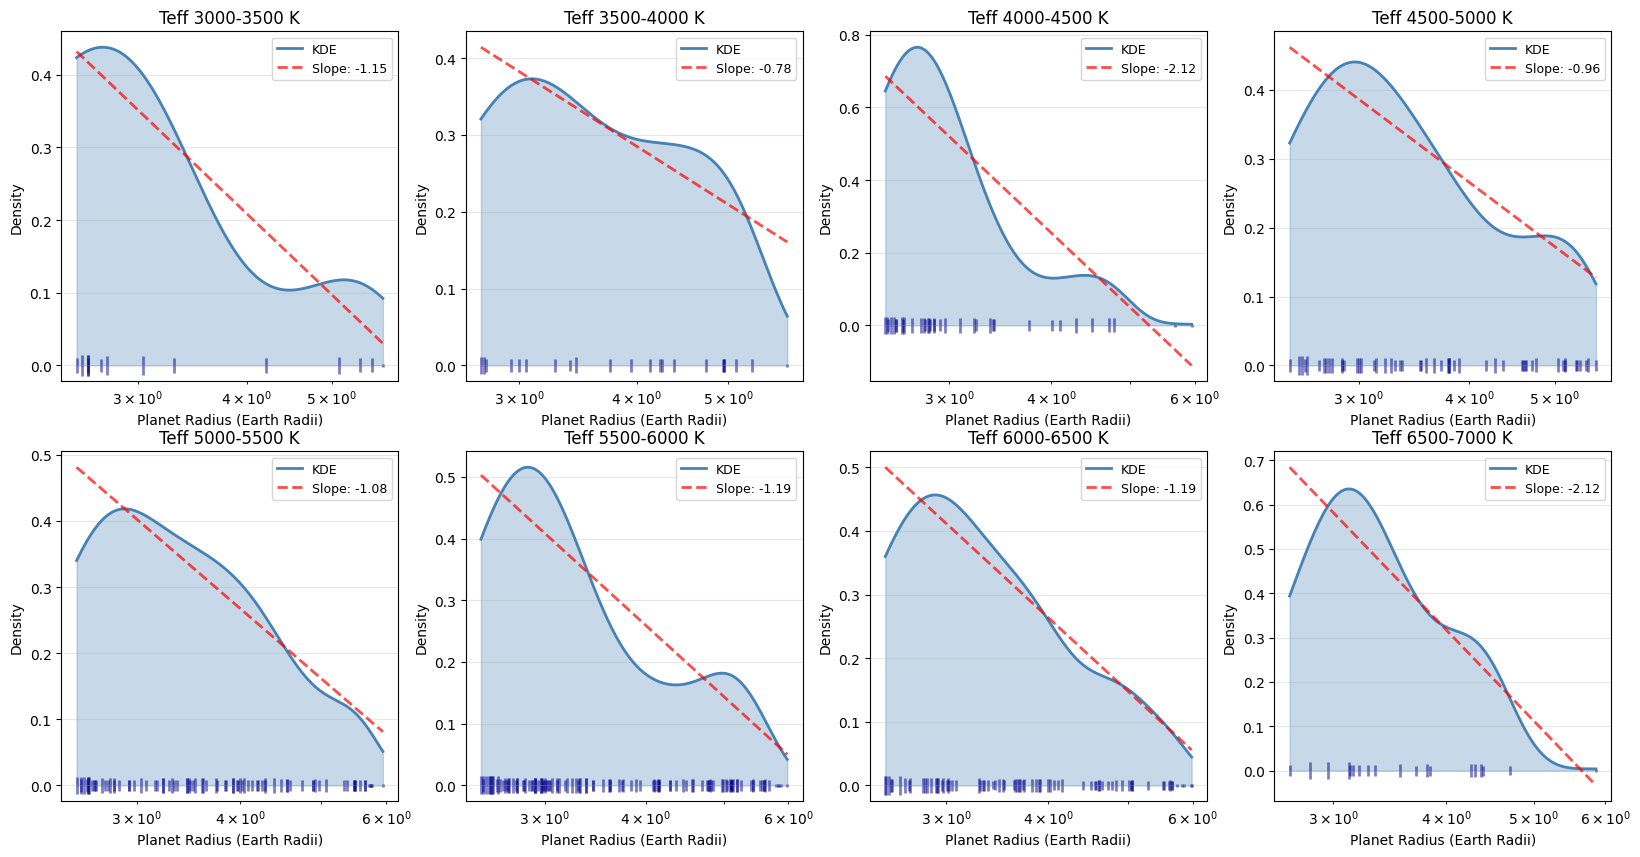

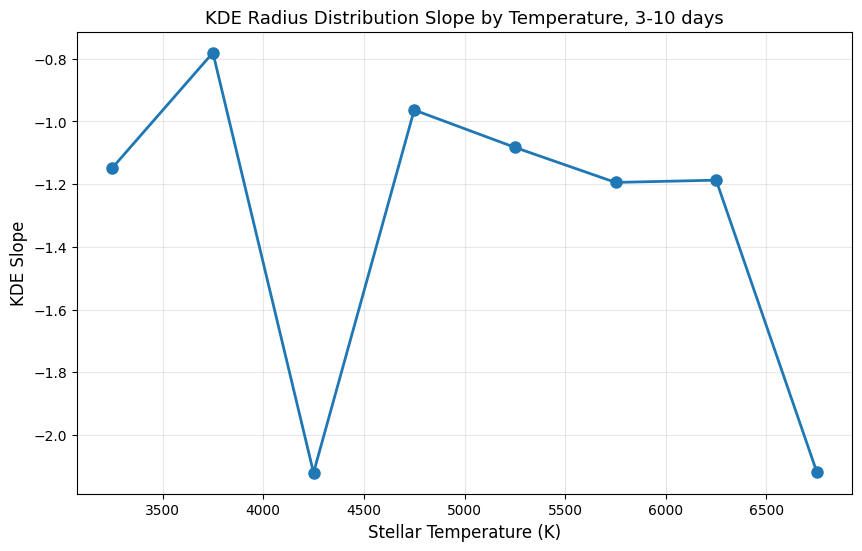

In [91]:
from scipy import stats

# Initialize array to store slopes
slopes_array = []

# Plot KDE for radius density space for each temperature bin
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, temp_range in enumerate(teff_ranges):
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    
    radii = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    
    if len(radii) > 0:
        # Create KDE for radius values
        kde = stats.gaussian_kde(radii, weights=weights)
        
        # Generate smooth x-axis values for plotting, 200 values
        x_min, x_max = radii.min(), radii.max()
        x_smooth = np.linspace(x_min, x_max, 200)
        # Evaluate KDE
        density = kde(x_smooth)

        
        # Plot KDE
        axes[idx].plot(x_smooth, density, linewidth=2, color='steelblue', label='KDE')
        axes[idx].fill_between(x_smooth, density, alpha=0.3, color='steelblue')
        
        # Calculate slope from KDE using log-log regression
        # Filter out zero or negative density values for log transform
        mask = density > 0
        #print(mask)
        if mask.sum() >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                np.log10(x_smooth[mask]), (density[mask])
            )
            r_squared = r_value**2
            
            # Save slope to array
            slopes_array.append(slope)
            
            # Plot the fit line
            x_fit = np.logspace(np.log10(x_smooth[mask].min()), np.log10(x_smooth[mask].max()), 100)
            y_fit = slope * np.log10(x_fit) + intercept
            axes[idx].plot(x_fit, y_fit, 'r--', linewidth=2, alpha=0.7, label=f'Slope: {slope:.2f}')
        else:
            slopes_array.append(np.nan)
                
        # Add individual data points as rug plot
        axes[idx].scatter(radii, np.zeros_like(radii), alpha=0.5, s=weights*5, 
                         color='darkblue', marker='|', linewidths=2)

        axes[idx].set_xlabel('Planet Radius (Earth Radii)', fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].set_title(f'Teff {temp_range[0]}-{temp_range[1]} K', fontsize=12)
        axes[idx].legend(fontsize=9)
        axes[idx].grid(alpha=0.3)
        axes[idx].set_xscale('log')
        #axes[idx].set_yscale('log')
        
        # Print statistics
        print(f"{temp_range[0]}-{temp_range[1]} K: Total corrected TOIs = {weights.sum():.1f}")

plt.show()
# Convert to numpy array

#print(f"\nSlopes array: {slopes_array}")

# Convert teff_ranges to average temperatures
temp_centers = [(temp_range[0] + temp_range[1]) / 2 for temp_range in teff_ranges]

plt.figure(figsize=(10, 6))
plt.plot(temp_centers, slopes_array, 'o-', linewidth=2, markersize=8)
plt.xlabel('Stellar Temperature (K)', fontsize=12)
plt.ylabel('KDE Slope', fontsize=12)
plt.title(f'KDE Radius Distribution Slope by Temperature, {lower_period_bound}-{upper_period_bound} days', fontsize=13)
plt.grid(alpha=0.3)
plt.show()

[(3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

3500-4000 K:
  Total corrected TOIs: 1359.8
  Log-log slope: -0.889

4000-4500 K:
  Total corrected TOIs: 2225.1
  Log-log slope: -1.503

4500-5000 K:
  Total corrected TOIs: 2888.8
  Log-log slope: -1.358

5000-5500 K:
  Total corrected TOIs: 5611.2
  Log-log slope: -0.692

5500-6000 K:
  Total corrected TOIs: 7399.2
  Log-log slope: -0.871

6000-6500 K:
  Total corrected TOIs: 4375.2
  Log-log slope: -0.988

6500-7000 K:
  Total corrected TOIs: 975.6
  Log-log slope: 3.630


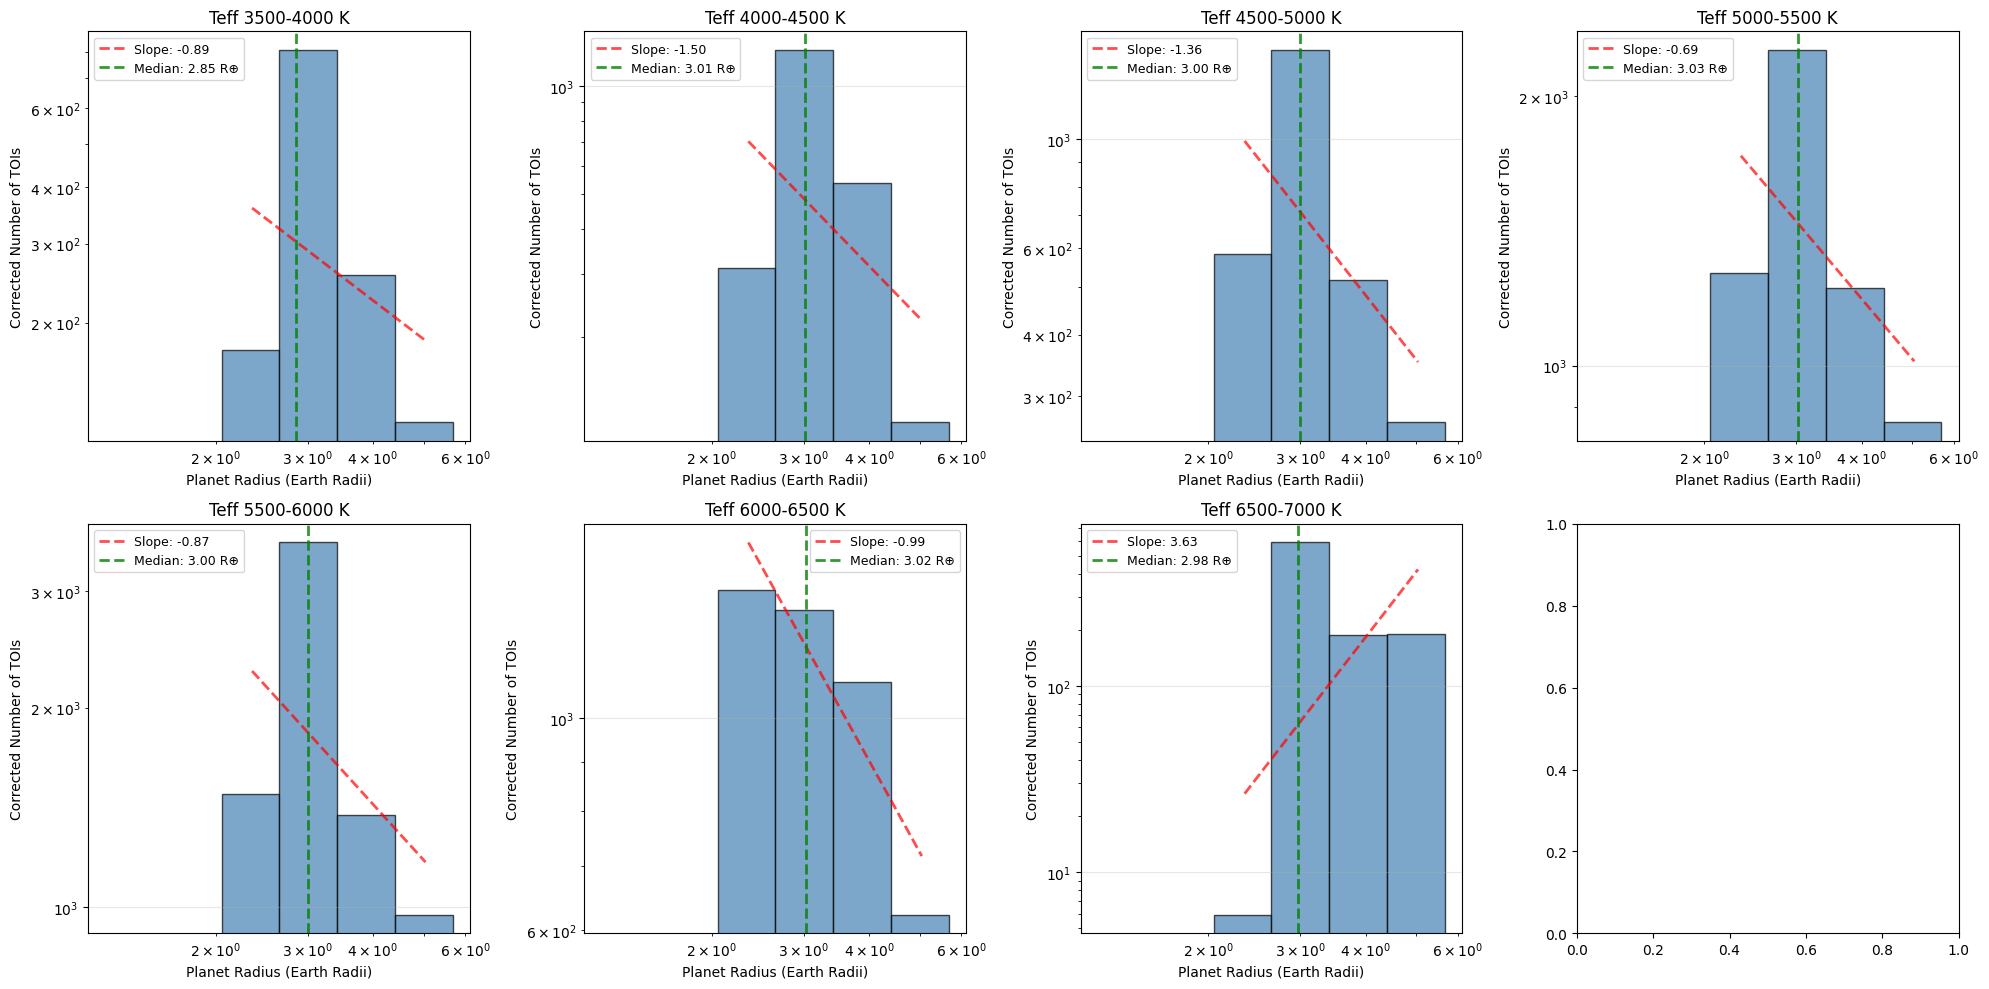


Summary of weighted median radii and slopes per temperature bin:
Teff Range  Weighted Median Radius (Earth Radii)     Slope  Intercept       R²
3500-4000K                              2.854732 -0.889205   2.885785 0.125290
4000-4500K                              3.014830 -1.502633   3.402816 0.243933
4500-5000K                              3.003360 -1.358291   3.500488 0.384672
5000-5500K                              3.026579 -0.691660   3.490630 0.328816
5500-6000K                              3.001043 -0.871294   3.679486 0.269564
6000-6500K                              3.023560 -0.988218   3.549778 0.820351
6500-7000K                              2.976680  3.629863   0.075206 0.357775


In [8]:
from scipy import stats

# Calculate slope of radius distribution for each temperature bin
temp_ranges = teff_ranges[1:]
print(temp_ranges)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

radius_medians_per_bin = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)', 'Slope', 'Intercept', 'R²'])

# Calculate bin centers from radius_bin_edges
bin_centers = np.array([(radius_bin_edges[i] + radius_bin_edges[i+1]) / 2 
                        for i in range(len(radius_bin_edges) - 1)])

for idx, temp_range in enumerate(temp_ranges):
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    
    n, bins, patches = axes[idx].hist(teff_df['pl_rade'], bins=radius_bin_edges, 
                                       weights=teff_df['weight'], alpha=0.7, 
                                       color='steelblue', edgecolor='black')
    
    # Calculate weighted median for this temperature bin
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            
        # Calculate slope using bin centers and counts
        if len(n[n > 0]) >= 2:  # Need at least 2 non-zero bins for slope
            # Use log scale for both axes (log-log fit)
            mask = n > 0
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                np.log10(bin_centers[mask]), np.log10(n[mask])
            )
            r_squared = r_value**2
            
            # Plot the fit line
            x_fit = np.logspace(np.log10(bin_centers[mask].min()), 
                               np.log10(bin_centers[mask].max()), 100)
            y_fit = 10**(intercept + slope * np.log10(x_fit))
            axes[idx].plot(x_fit, y_fit, 'r--', linewidth=2, alpha=0.7, 
                          label=f'Slope: {slope:.2f}')
        else:
            slope, intercept, r_squared = np.nan, np.nan, np.nan
        
        radius_medians_per_bin = pd.concat([
            radius_medians_per_bin,
            pd.DataFrame({
                'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
                'Weighted Median Radius (Earth Radii)': [weighted_median],
                'Slope': [slope],
                'Intercept': [intercept],
                'R²': [r_squared]
            })], ignore_index=True)
        
        axes[idx].axvline(weighted_median, linestyle='--', linewidth=2, color='green', 
                         label=f'Median: {weighted_median:.2f} R⊕', alpha=0.8)
    
    axes[idx].set_xlabel('Planet Radius (Earth Radii)', fontsize=10)
    axes[idx].set_ylabel('Corrected Number of TOIs', fontsize=10)
    axes[idx].set_title(f'Teff {temp_range[0]}-{temp_range[1]} K', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    
    # Print statistics for this bin
    print(f"\n{temp_range[0]}-{temp_range[1]} K:")
    print(f"  Total corrected TOIs: {teff_df['weight'].sum():.1f}")
    if len(vals) > 0 and weights.sum() > 0:
        #print(f"  Weighted median radius: {weighted_median:.2f} R⊕")
        print(f"  Log-log slope: {slope:.3f}")
        #print(f"  R²: {r_squared:.3f}")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Summary of weighted median radii and slopes per temperature bin:")
print(radius_medians_per_bin.to_string(index=False))

[(3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

3500-4000 K:
  Total corrected TOIs: 1359.8
  Log-log slope: -2.705

4000-4500 K:
  Total corrected TOIs: 2225.1
  Log-log slope: -1.844

4500-5000 K:
  Total corrected TOIs: 2888.8
  Log-log slope: -1.711

5000-5500 K:
  Total corrected TOIs: 5611.2
  Log-log slope: -2.056

5500-6000 K:
  Total corrected TOIs: 7399.2
  Log-log slope: -2.538

6000-6500 K:
  Total corrected TOIs: 4375.2
  Log-log slope: -2.255

6500-7000 K:
  Total corrected TOIs: 975.6
  Log-log slope: -2.862


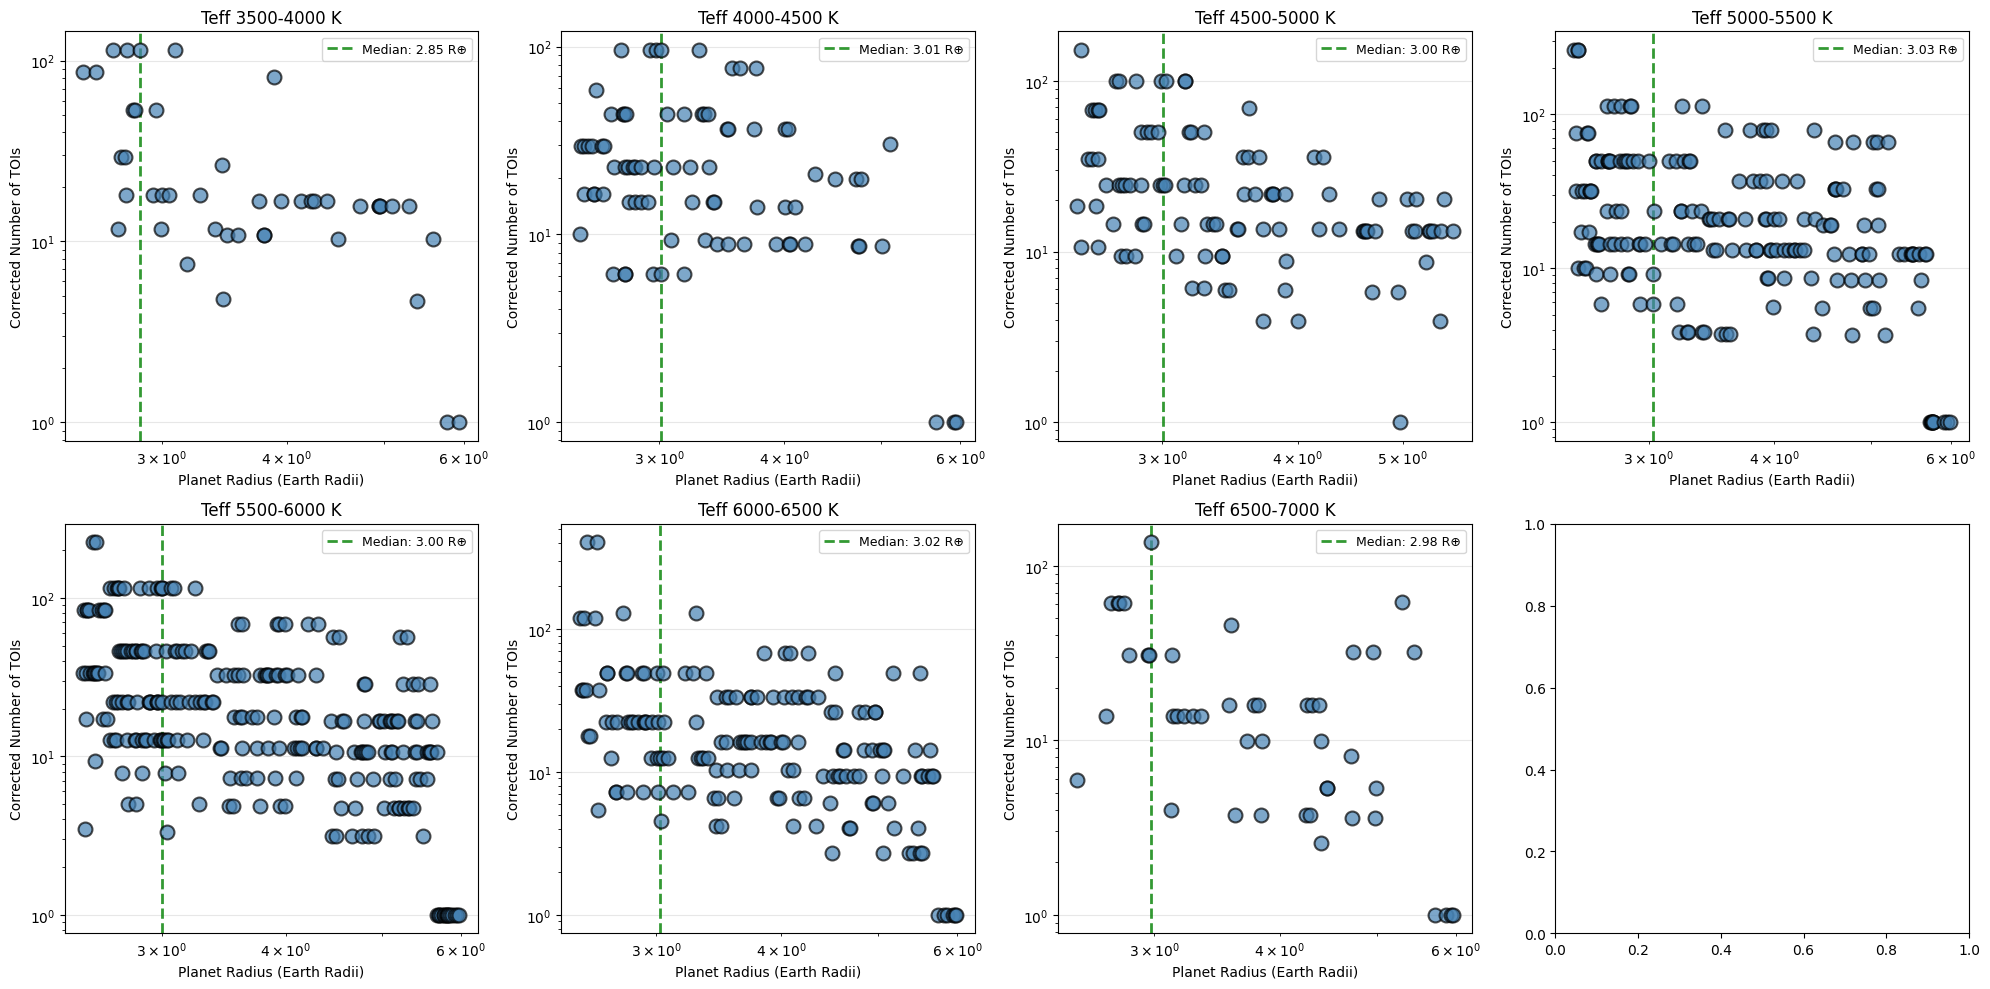


Summary of weighted median radii and slopes per temperature bin:
Teff Range  Weighted Median Radius (Earth Radii)     Slope  Intercept       R²
3500-4000K                              2.854732 -2.705328   2.788023 0.416417
4000-4500K                              3.014830 -1.843987   2.240783 0.180637
4500-5000K                              3.003360 -1.710516   2.226063 0.209899
5000-5500K                              3.026579 -2.055909   2.401145 0.219151
5500-6000K                              3.001043 -2.537695   2.666863 0.350694
6000-6500K                              3.023560 -2.254675   2.483426 0.273799
6500-7000K                              2.976680 -2.862272   2.729953 0.331446


In [9]:
from scipy import stats

# Calculate slope of radius distribution for each temperature bin
temp_ranges = teff_ranges[1:]
print(temp_ranges)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

radius_medians_per_bin = pd.DataFrame(columns=['Teff Range', 'Weighted Median Radius (Earth Radii)', 'Slope', 'Intercept', 'R²'])

# Calculate bin centers from radius_bin_edges
bin_centers = np.array([(radius_bin_edges[i] + radius_bin_edges[i+1]) / 2 
                        for i in range(len(radius_bin_edges) - 1)])

for idx, temp_range in enumerate(temp_ranges):
    teff_df = merged_df[(merged_df['st_teff'] >= temp_range[0]) & (merged_df['st_teff'] < temp_range[1])]
    
    # Calculate weighted median for this temperature bin
    vals = teff_df['pl_rade'].values
    weights = teff_df['weight'].values
    if len(vals) > 0 and weights.sum() > 0:
        sorted_idx = np.argsort(vals)
        vals_sorted = vals[sorted_idx]
        weights_sorted = weights[sorted_idx]
        cumsum = np.cumsum(weights_sorted)
        cutoff = weights_sorted.sum() / 2.0
        weighted_median = vals_sorted[np.searchsorted(cumsum, cutoff)]
            
        # Calculate slope using discrete radius values and their weights
        if len(vals) >= 2:  # Need at least 2 data points for slope
            # Create weighted frequency distribution for each discrete radius value
            unique_radii = np.unique(vals)
            weighted_counts = []
            for radius in unique_radii:
                mask = vals == radius
                weighted_counts.append(weights[mask].sum())
            weighted_counts = np.array(weighted_counts)
            
            # Plot discrete values as scatter points
            axes[idx].scatter(unique_radii, weighted_counts, s=100, alpha=0.7,
                             color='steelblue', edgecolors='black', linewidths=1.5, zorder=3)
            
            # Use log scale for both axes (log-log fit)
            mask = weighted_counts > 0
            if mask.sum() >= 2:
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    np.log10(unique_radii[mask]), np.log10(weighted_counts[mask])
                )
                r_squared = r_value**2
                
                # Plot the fit line
                x_fit = np.logspace(np.log10(unique_radii[mask].min()), 
                                   np.log10(unique_radii[mask].max()), 100)
                y_fit = 10**(intercept + slope * np.log10(x_fit))
                #axes[idx].plot(x_fit, y_fit, 'r--', linewidth=2, alpha=0.7, 
                #              label=f'Slope: {slope:.2f}')
            else:
                slope, intercept, r_squared = np.nan, np.nan, np.nan
        else:
            slope, intercept, r_squared = np.nan, np.nan, np.nan
        
        radius_medians_per_bin = pd.concat([
            radius_medians_per_bin,
            pd.DataFrame({
                'Teff Range': [f"{temp_range[0]}-{temp_range[1]}K"],
                'Weighted Median Radius (Earth Radii)': [weighted_median],
                'Slope': [slope],
                'Intercept': [intercept],
                'R²': [r_squared]
            })], ignore_index=True)
        
        axes[idx].axvline(weighted_median, linestyle='--', linewidth=2, color='green', 
                         label=f'Median: {weighted_median:.2f} R⊕', alpha=0.8)
    
    axes[idx].set_xlabel('Planet Radius (Earth Radii)', fontsize=10)
    axes[idx].set_ylabel('Corrected Number of TOIs', fontsize=10)
    axes[idx].set_title(f'Teff {temp_range[0]}-{temp_range[1]} K', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    
    # Print statistics for this bin
    print(f"\n{temp_range[0]}-{temp_range[1]} K:")
    print(f"  Total corrected TOIs: {teff_df['weight'].sum():.1f}")
    if len(vals) > 0 and weights.sum() > 0:
        #print(f"  Weighted median radius: {weighted_median:.2f} R⊕")
        print(f"  Log-log slope: {slope:.3f}")
        #print(f"  R²: {r_squared:.3f}")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Summary of weighted median radii and slopes per temperature bin:")
print(radius_medians_per_bin.to_string(index=False))

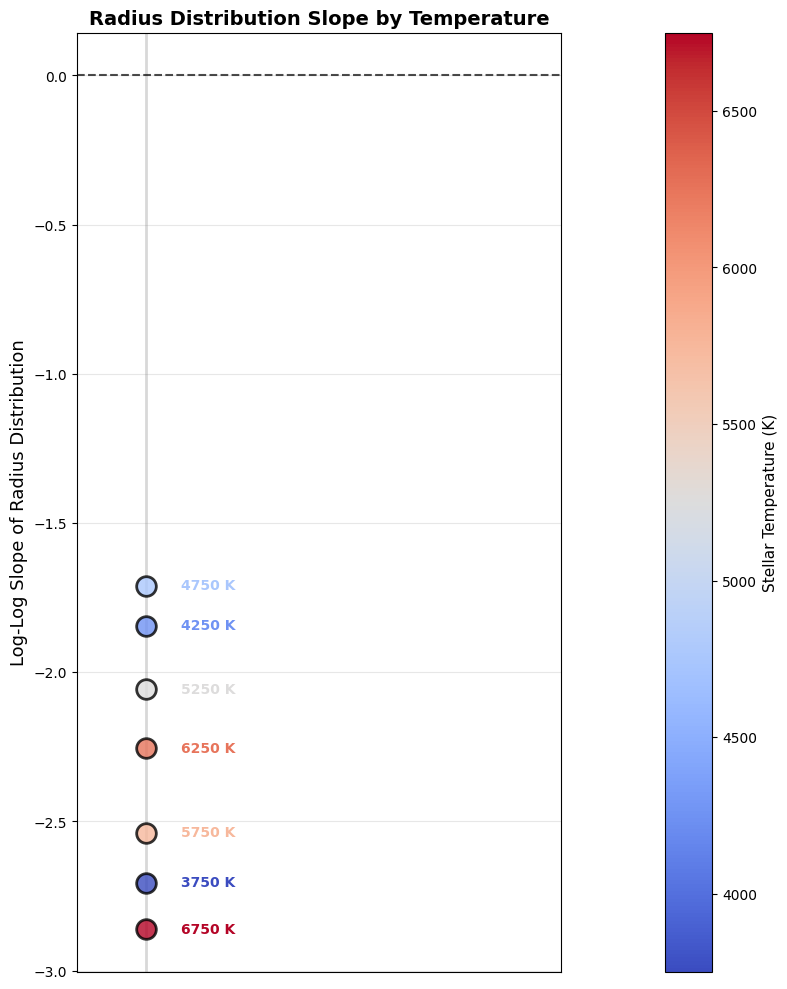


Slope vs Temperature Summary:
  3750 K: Slope = -2.705, R² = 0.416
  4250 K: Slope = -1.844, R² = 0.181
  4750 K: Slope = -1.711, R² = 0.210
  5250 K: Slope = -2.056, R² = 0.219
  5750 K: Slope = -2.538, R² = 0.351
  6250 K: Slope = -2.255, R² = 0.274
  6750 K: Slope = -2.862, R² = 0.331


In [10]:
# Plot slopes as vertical line, color-coded by temperature
fig, ax = plt.subplots(figsize=(8, 10))

# Extract temperature bin centers
temp_centers = []
for idx, row in radius_medians_per_bin.iterrows():
    teff_range = row['Teff Range']
    # Extract min and max from string like "3500-4000K"
    temps = teff_range.replace('K', '').split('-')
    temp_center = (int(temps[0]) + int(temps[1])) / 2
    temp_centers.append(temp_center)

# Create vertical line plot with color mapping
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Normalize temperature for color mapping
norm = Normalize(vmin=min(temp_centers), vmax=max(temp_centers))
cmap = cm.coolwarm

# Plot each slope as a horizontal line at x=0
for i, (temp, slope, r2) in enumerate(zip(temp_centers, 
                                           radius_medians_per_bin['Slope'], 
                                           radius_medians_per_bin['R²'])):
    color = cmap(norm(temp))
    ax.scatter([0], [slope], c=[color], s=200, edgecolors='black', linewidths=2, alpha=0.8, zorder=3)
    
    # Add temperature label on the right
    ax.text(0.05, slope, f'{int(temp)} K', 
            fontsize=10, va='center', ha='left', color=color, weight='bold')

# Add vertical line at x=0
ax.axvline(0, color='gray', linestyle='-', alpha=0.3, linewidth=2)

# Add horizontal line at y=0 for reference
ax.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1.5)

# Labels and formatting
ax.set_ylabel('Log-Log Slope of Radius Distribution', fontsize=13)
ax.set_title('Radius Distribution Slope by Temperature', fontsize=14, weight='bold')
ax.set_xlim(-0.1, 0.6)
ax.set_xticks([])  # Remove x-axis ticks
ax.grid(True, alpha=0.3, axis='y')

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.15)
cbar.set_label('Stellar Temperature (K)', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print("\nSlope vs Temperature Summary:")
for temp, slope, r2 in zip(temp_centers, radius_medians_per_bin['Slope'], radius_medians_per_bin['R²']):
    print(f"  {temp:.0f} K: Slope = {slope:.3f}, R² = {r2:.3f}")